# Model Explainability

## Objective

The purpose of this notebook is to interpret the trained machine learning model rather than improve its predictive performance.

While evaluation metrics quantify how accurately the model predicts gas giant occurrence, explainability techniques provide insight into *why* specific predictions are made and which stellar properties contribute most strongly to the model's decisions.

The analyses in this notebook focus on the best-performing model developed in the previous notebook. Both global and local explainability methods are used to investigate how stellar temperature, stellar radius, and stellar metallicity influence predictions.

Understanding these relationships improves transparency, supports scientific interpretation, and helps determine whether the model's behavior is consistent with current astrophysical knowledge.

In [1]:
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

In [2]:
best_model = joblib.load("../models/random_forest.joblib")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Model type:", type(best_model))

X_test shape: (765, 3)
y_test shape: (765,)
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [4]:
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7372549019607844

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.74      0.82       609
           1       0.42      0.74      0.54       156

    accuracy                           0.74       765
   macro avg       0.67      0.74      0.68       765
weighted avg       0.82      0.74      0.76       765



In [5]:
importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,st_rad,0.433039
2,st_met,0.293329
0,st_teff,0.273632


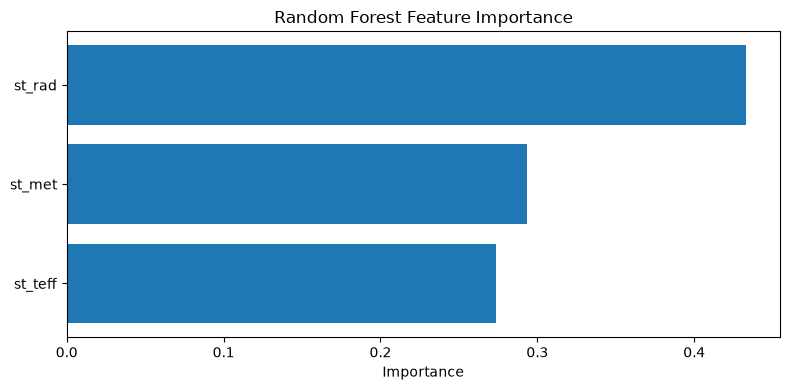

In [6]:
plt.figure(figsize=(8, 4))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [7]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std
})

perm_importance = perm_importance.sort_values(
    by="Importance Mean",
    ascending=False
)

perm_importance

,Feature,Importance Mean,Importance Std
1,st_rad,0.157386,0.003930
0,st_teff,0.054118,0.008556
2,st_met,0.049804,0.013628


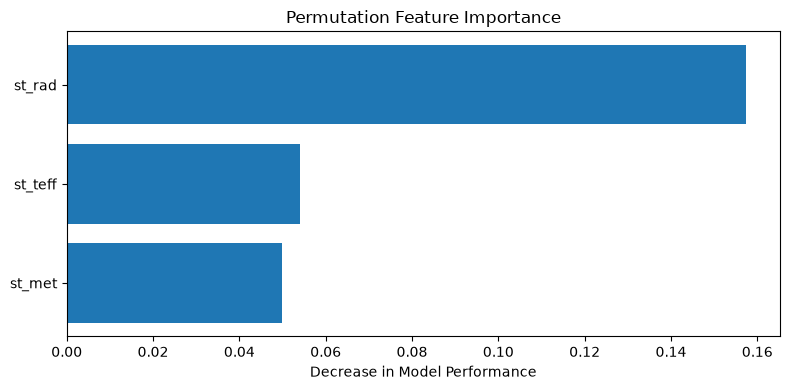

In [8]:
plt.figure(figsize=(8, 4))

plt.barh(
    perm_importance["Feature"],
    perm_importance["Importance Mean"]
)

plt.xlabel("Decrease in Model Performance")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

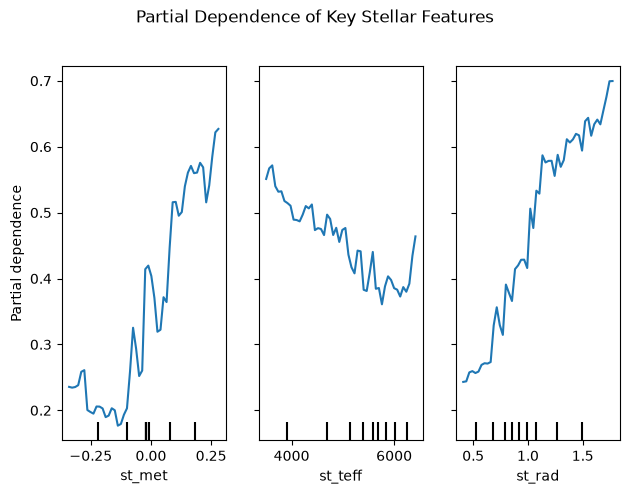

In [9]:
features_to_plot = [
    "st_met",
    "st_teff",
    "st_rad"
]

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features_to_plot,
    kind="average",
    grid_resolution=50
)

plt.suptitle("Partial Dependence of Key Stellar Features", y=1.02)
plt.tight_layout()
plt.show()

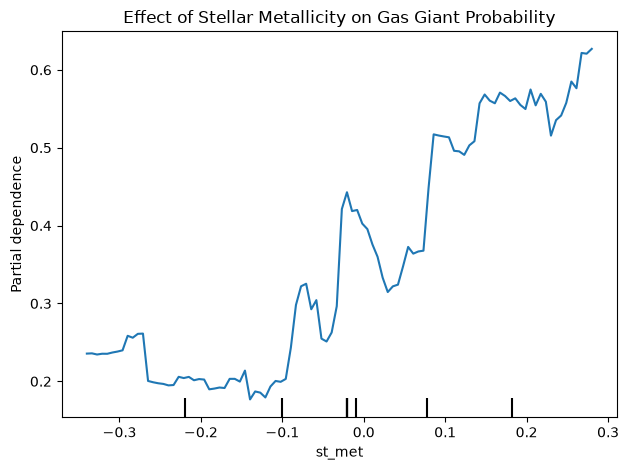

In [10]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    ["st_met"],
    kind="average",
    grid_resolution=100
)

plt.title("Effect of Stellar Metallicity on Gas Giant Probability")
plt.tight_layout()
plt.show()

In [43]:
features = list(X_test.columns)

# --------------------------
# RF Importance
# --------------------------
rf_df = pd.DataFrame({
    "Feature": features,
    "RF Importance": best_model.feature_importances_
})

# --------------------------
# Permutation Importance
# --------------------------
perm_dict = dict(zip(
    perm_importance["Feature"],
    perm_importance["Importance Mean"]
))

perm_df = pd.DataFrame({
    "Feature": features,
    "Permutation Importance": [perm_dict.get(f, np.nan) for f in features]
})

# --------------------------
# SHAP (FORCED SAFE EXTRACTION)
# --------------------------
explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_test, check_additivity=False)

# handle binary classification
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw

shap_vals = np.array(shap_vals)

# FORCE to 2D if accidentally 3D
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 0]

# FINAL GUARANTEE: must be (n_samples, n_features)
shap_vals = shap_vals.reshape(shap_vals.shape[0], -1)

# reduce to feature importance vector
shap_importance = np.mean(np.abs(shap_vals), axis=0)

# SAFETY CHECK
shap_importance = np.ravel(shap_importance)

# FINAL ALIGNMENT
min_len = min(len(features), len(shap_importance))

shap_df = pd.DataFrame({
    "Feature": features[:min_len],
    "SHAP Importance": shap_importance[:min_len]
})

# --------------------------
# OUTPUT
# --------------------------
rf_df, perm_df, shap_df

(   Feature  RF Importance
 0  st_teff       0.273632
 1   st_rad       0.433039
 2   st_met       0.293329,
    Feature  Permutation Importance
 0  st_teff                0.054118
 1   st_rad                0.157386
 2   st_met                0.049804,
    Feature  SHAP Importance
 0  st_teff         0.051649
 1   st_rad         0.136165
 2   st_met         0.097303)